In [ ]:
!pip install ultralytics --q
!pip install roboflow --q
from ultralytics import YOLO
from roboflow import Roboflow
!pip install inference-sdk --q

In [ ]:
model = YOLO("yolo11s.pt")

In [ ]:
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="R3Y4NKr6fteoLQ9XjC3J")
project = rf.workspace("omars-workspace-57jsf").project("new_data-l8ohm")
version = project.version(3)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to New_data-3 in yolov11:: 100%|██████████| 2837/2837 [00:00<00:00, 6268.94it/s]


In [ ]:
model.train(data='/content/New_data-3/data.yaml',epochs=58,
    imgsz=900,
    batch=16,
    device=0,
    workers=2,optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,
    cos_lr=True,
    patience=13,
    cache=True,
    amp=True,
    close_mosaic=10,
    name="football_detector_v2"
)

Ultralytics 8.4.110 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/New_data-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=58, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=900, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=football_detector_v2, nbs=64, nm

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d02cc1b5a60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0


image 1/1 /content/images.jpg: 928x928 16 players, 27.9ms
Speed: 5.1ms preprocess, 27.9ms inference, 1.3ms postprocess per image at shape (1, 3, 928, 928)


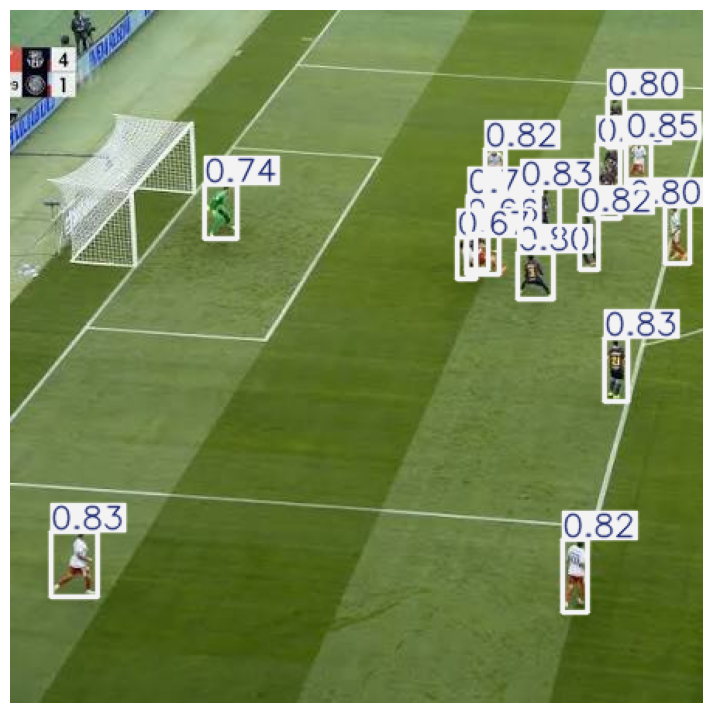

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO("runs/detect/football_detector_v2/weights/best.pt")

# Predict on your own image
results = model.predict(
    source="/content/images.jpg",
    conf=0.4,
    save=False
)

# Draw detections
annotated = results[0].plot(
    labels=False,
    line_width=2
)
# Display
annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 9))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files
import shutil
shutil.copy(
    "runs/detect/football_detector_v2/weights/best.pt",
    "/content/football_detector_best.pt"
)
files.download("/content/football_detector_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>